# Prediction Module

    The main goal of the prediction module is to use the PropaPhenKG+ and the observations found in the detection module to cluster the observations into similar phenomenon clusters

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Libraries

### Installing

In [20]:
#!pip install pandas
#!pip install tqdm
#!pip install -U scikit-learn
#!pip install matplotlib

### Standard

In [21]:
import pandas as pd
import numpy as np
from functools import partial

### Custom libraries

In [22]:
sys.path.append('../lib/')
from prediction.predictionmodule import PredictionModule,BenchMark
from prediction.embedding.bow import ObservationBoWEmbedding
from prediction.embedding.kgembedding import ObservationHomogeneousEmbedding, ObservationHeterogeneousEmbedding
from prediction.embedding.semantic import ObservationLCEmbedding,ObservationHSEmbedding, ObservationRelTopicEmbedding
from prediction.clustering import KMeansClustering

## Globals

In [23]:
path_to_kb_gazetteer = "../data/detection/gazetteers/kbgazetteer.csv"
path_to_netwoork_gazetteer = "../data/detection/gazetteers/world_gazetteer.csv"
path_to_observationcsv = "../Detection/data/csv/observations_phrase.csv"
path_to_worldkg_nodes = "../Description/data/worldkg_nodes.csv"

In [24]:
path_to_observations = "../data/detection/outputs/observations/"

In [25]:
# Homogeneous embeddings
kb_fastrp_embedding_path="../data/prediction/embeddings/fastrp/umls-fastrp_embedding.csv"
net_fastrp_embedding_path="../data/prediction/embeddings/fastrp/worldkg-fastrp_embedding.csv"
kb_node2vec_embedding_path="../data/prediction/embeddings/node2vec/umls-node2vec.csv"
net_node2vec_embedding_path="../data/prediction/embeddings/node2vec/worldkg-node2vec.csv"

In [26]:
# Heterogeneous embeddings
kb_hashgnn_embedding_path="../data/prediction/embeddings/hashgnn/umls-hashgnn.csv"
net_hashgnn_embedding_path="../data/prediction/embeddings/hashgnn/worldkg-hashgnn.csv"
kb_graphsage_embedding_path="../data/prediction/embeddings/graphsage/umls_graphsage.csv"
net_graphsage_embedding_path="../data/prediction/embeddings/graphsage/worldkg_graphsage.csv"

In [27]:
# Semantic embeddings
kb_concept_path="../data/prediction/embeddings/semantic/semantic_types_export.csv"
net_concept_path="../data/prediction/embeddings/semantic/world_semantic_type.csv"
## Distance
kb_distance_path="../data/prediction/embeddings/semantic/shortestpath.csv"
net_distance_path="../data/prediction/embeddings/semantic/world_shortestdistance.csv"
# Turns
kb_turns_path = "../data/prediction/embeddings/semantic/turns.csv"
net_turns_path = "../data/prediction/embeddings/semantic/world_turns.csv"
# RelTopic
kb_dijkstra_path = "../data/prediction/embeddings/semantic/dijkstra.csv"
net_dijkstra_path = "../data/prediction/embeddings/semantic/world_dijkstra.csv"
kb_neighborhood_path = "../data/prediction/embeddings/semantic/neighborhood.csv"
net_neighborhood_path = "../data/prediction/embeddings/semantic/world_neighborhood.csv"
kb_specialdegree_path = "../data/prediction/embeddings/semantic/specialdegree.csv"
net_specialdegree_path = "../data/prediction/embeddings/semantic/world_special_degree.csv"
# Wang
kb_sa_path = "../data/prediction/embeddings/semantic/umls_sa.csv"
net_sa_path = "../data/prediction/embeddings/semantic/world_sa.csv"
kb_sva_path = "../data/prediction/embeddings/semantic/umls_sva.csv"
net_sva_path = "../data/prediction/embeddings/semantic/world_sva.csv"

In [28]:
# BioLLM
kb_id_to_type = "../data/prediction/embeddings/semantic/semantic_id_to_types.csv"

## Observation Embedding

    It should get the observations and the PropaPhenKG+ to transform the observations into observation vectors

In [29]:
predictionModule = PredictionModule(path_to_kb_gazetteer,
                path_to_netwoork_gazetteer,
                path_to_observations)

In [30]:
embedder =  ObservationRelTopicEmbedding(predictionModule,kb_concept_path,net_concept_path,kb_dijkstra_path,net_dijkstra_path,
                                                          kb_neighborhood_path,net_neighborhood_path,
                                                                       kb_specialdegree_path,net_specialdegree_path,aggregation_method='average')        

In [31]:
df_kb, df_net = embedder.loadEmbeddings()

Loading concept mappings from ../data/prediction/embeddings/semantic/semantic_types_export.csv and ../data/prediction/embeddings/semantic/world_semantic_type.csv...
Loaded 9644710 KB concept mappings and 1294509 Network concept mappings.


In [32]:
def strip_quotes(value):
    """
    Remove all double and single quotes from a string, a pandas Series, or elements in a list.
    """
    if isinstance(value, str):
        return value.replace('"', '').replace("'", "")
    elif isinstance(value, list):
        # Recursively strip quotes from each element in the list
        return [self._strip_quotes(v) for v in value]
    elif isinstance(value, pd.Series):
        # Apply stripping to each element in the Series
        return value.apply(lambda x: self._strip_quotes(x))
    else:
        return value

In [33]:
import re
import pandas as pd

# Assuming the file is a CSV; adjust delimiter if needed
df_kb_id_to_type = pd.read_csv(kb_id_to_type, delimiter=',', header=None, dtype=str)

# Apply the function to clean up quotes in the entire DataFrame
df_kb_id_to_type = df_kb_id_to_type.applymap(strip_quotes)

# Function to parse list-like strings into actual Python lists
def parse_list(value):
    if not isinstance(value, str):
        return [value]  # Ensure it's always a list
    
    value = value.strip()

    # If the string is in a list format but not a valid Python list, clean and split it
    if value.startswith('[') and value.endswith(']'):
        cleaned_value = re.sub(r'[\[\]\']', '', value)  # Remove brackets and single quotes
        return [item.strip() for item in cleaned_value.split(',')]

    # If it's a comma-separated string, split it
    if ',' in value:
        return [item.strip() for item in value.split(',')]

    # Otherwise, return as a single-element list
    return [value]

# Apply parsing function to the third column
df_kb_id_to_type.iloc[:, 2] = df_kb_id_to_type.iloc[:, 2].apply(parse_list)

# Convert the DataFrame to a dictionary with first column as keys and third column as values
kb_id_to_type_dict = dict(zip(df_kb_id_to_type.iloc[:, 0], df_kb_id_to_type.iloc[:, 2]))

In [34]:
from prediction.utils import obsToList
import os
from tqdm import tqdm

def obs_to_folder(df_obs,df_kb,kb_id_to_type_dict,folder_name,
                  str_id="_CONCEPTS_",getFullConceptList=True, addEntity=False):
    # Populate the observation matrix
    chemin = "../data/prediction/observation_txt/"
    # Check whether the specified path exists or not
    isExist = os.path.exists(chemin+folder_name)
    if not isExist:
       # Create a new directory because it does not exist
       os.makedirs(chemin+folder_name)
    for _, row in tqdm(df_obs.iterrows()):
        
        # Original file for component analysis
        system_kb_items = obsToList(row['KB_Components'])
        fichier = ""
        fichier_concept = ""
        for kb_item in system_kb_items:
            fichier += kb_item + "\n"
            if addEntity:
                fichier_concept += kb_item + "\n"
        # Saving original file
        file_name = row['Observation_Name'] + "_"+ str(row['average_date'])
        with open(chemin+folder_name+"/"+file_name+".txt", "w") as text_file:
            text_file.write(fichier)
            
        # New file for concept analysis
        
        kb_components = obsToList(row['KB_IDs'])
        obs_concept_list = []
        for component in kb_components:
            component = strip_quotes(component)
            matching_kb_rows = df_kb[df_kb['component'] == component]
            if matching_kb_rows.empty:
                continue
            concepts_id = [strip_quotes(x) for x in ast.literal_eval(matching_kb_rows.iloc[0]['concept'])]
            for concept_id in concepts_id:
                list_to_join = kb_id_to_type_dict[concept_id]
                if (not getFullConceptList) and len(list_to_join) > 0:
                    list_to_join = [list_to_join[0]]
                obs_concept_list += list_to_join
        obs_concept_list = list(set(obs_concept_list))
        obs_concept_list = sorted(obs_concept_list)
        for concept in obs_concept_list:
            fichier_concept += concept + "\n";
        # Saving file for concept
        file_name = row['Observation_Name'] + str_id +str(row['average_date'])
        with open(chemin+folder_name+"/"+file_name+".txt", "w") as text_file:
            text_file.write(fichier_concept)
        

def obs_concept_to_folder(df_obs,folder_name):
    # Populate the observation matrix
    chemin = "../data/prediction/observation_txt/"
    # Check whether the specified path exists or not
    isExist = os.path.exists(chemin+folder_name)
    if not isExist:
       # Create a new directory because it does not exist
       os.makedirs(chemin+folder_name)
    for _, row in tqdm(df_obs.iterrows()):
        system_kb_items = obsToList(row['KB_Components'])
        fichier = ""
        for kb_item in system_kb_items:
            fichier += kb_item + "\n"
        file_name = row['Observation_Name'] + "_"+ str(row['average_date'])
        with open(chemin+folder_name+"/"+file_name+".txt", "w") as text_file:
            text_file.write(fichier)

In [35]:
predictionModule.re_dict.keys()

dict_keys(['DocumentMatching', 'ParagraphMatching', 'SentenceMatching'])

In [19]:
import ast
for key in predictionModule.re_dict.keys():
    obs_to_folder(predictionModule.re_dict[key],df_kb,kb_id_to_type_dict,key,
                 str_id="_SINGLE_CONCEPT_",getFullConceptList=False, addEntity=True)

339it [1:03:10, 11.18s/it]
71it [10:01,  8.47s/it]
126it [15:26,  7.35s/it]


In [20]:
import ast
for key in predictionModule.re_dict.keys():
    obs_to_folder(predictionModule.re_dict[key],df_kb,kb_id_to_type_dict,key,
                 str_id="_CONCEPTS_",getFullConceptList=True, addEntity=True)

339it [1:02:21, 11.04s/it]
71it [09:55,  8.39s/it]
126it [15:15,  7.26s/it]


In [19]:
predictionModule.re_dict['DocumentMatching']

,Unnamed: 0,System_Name,System_ID,average_date,KB_Components,KB_IDs,intensity,Observation_Name
0,0,"""Australia""",wkg:424315584,19.916667,"['aluminum hexafluorosilicate(2-) (3:2)', 'www...","['A1327850', 'A18580952', 'A34748310', 'A83231...","[62, 64, 68, 68, 76, 80, 80, 80, 80, 84, 86, 8...",Journal_COVID_Australia
1,1,"""Belgium""",wkg:1684793666,19.916667,['https://github.com/geneontology/go-ontology/...,"['A34454909', 'A18580952', 'A34748310', 'C3639...","[124, 128, 136, 152, 160, 160, 160, 160, 168, ...",Journal_COVID_Belgium
2,2,"""Bulgaria""",wkg:424315709,19.916667,"['aluminum hexafluorosilicate(2-) (3:2)', 'www...","['C0608509', 'A18580952', 'A34748310', 'C08707...","[434, 448, 476, 476, 532, 560, 560, 560, 560, ...",Journal_COVID_Bulgaria
3,3,"""Canada""",wkg:424313760,19.916667,"['aluminum hexafluorosilicate(2-) (3:2)', 'IV:...","['C0608509', 'A18580952', 'A34748310', 'A21421...","[62, 68, 68, 76, 76, 80, 80, 80, 80, 84, 86, 8...",Journal_COVID_Canada
4,4,"""China""",wkg:424313582,19.916667,"['researchers', 'caused by', 'said', 'bat', 'R...","['A18668123', 'A18613966', 'A18647070', 'A1862...","[252, 264, 264, 270, 272, 278, 288, 288, 348, ...",Journal_COVID_China
...,...,...,...,...,...,...,...,...
334,33,"""Ukraine""",wkg:1648342273,22.416667,"['Health', 'PODCI Pediatric Parent-Reported Ve...","['A12925389', 'A13987869', 'A18597116', 'A1860...","[5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 8, ...",Journal_Monkeypox_Ukraine
335,34,"""United Arab Emirates""",wkg:424310703,22.416667,"['rash', 'O/E: E.M. micr.: virus', 'cases', 'v...","['A18674382', 'A18587731', 'A18650525', 'A4831...","[5, 6, 6, 6, 10]",Journal_Monkeypox_United Arab Emirates
336,35,"""United Kingdom""",wkg:838090640,22.416667,"['disease', 'cardiac catheterization post-proc...","['A18683747', 'A13987869', 'A18647936', 'A3356...","[100, 102, 102, 109, 114, 122, 122, 122, 127, ...",Journal_Monkeypox_United Kingdom
337,36,"""United States""",wkg:424317935,22.416667,"['hospital', 'contact with', 'fever', 'disease...","['A28753931', 'A12925770', 'A18563007', 'A1868...","[287, 302, 302, 329, 331, 343, 344, 362, 362, ...",Journal_Monkeypox_United States


In [43]:
from prediction.utils import obsToList
import ast
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import classification_report
import numpy as np
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import ast
from tqdm import tqdm

In [44]:
def clusterObservations(embedding_df, k=2, random_seed=42, include_spatial=True, include_temporal=True):
    """
    Cluster observations using k-medoids and evaluate the clusters.
    
    :param embedding_matrix: The matrix of embeddings for observations.
    :param df_obs: DataFrame containing observation data.
    :param k: Number of clusters for k-medoids.
    :param random_seed: Random seed for reproducibility.
    :param include_temporal: If True, includes date in the distance calculation.
    :return: Cluster labels, the best type list, and the best F1 score.
    """

    #distance_matrix = 1-embedding_df.drop(embedding_df.columns[0],axis=1).to_numpy(dtype=float)
    # Drop the first column explicitly by name ('Unnamed: 0') and ensure numeric conversion
    numeric_df = embedding_df.drop(columns=['Unnamed: 0']).apply(pd.to_numeric, errors='coerce').fillna(0)
    distance_matrix = 1 - numeric_df.to_numpy()
    # Rescale the entire distance matrix to the range [0, 1]
    max_distance = np.max(distance_matrix)
    min_distance = np.min(distance_matrix)
    if max_distance > min_distance:  # Avoid division by zero
        distance_matrix = (distance_matrix - min_distance) / (max_distance - min_distance)
    
    print("Clustering observations with k-medoids...")
    kmedoids = KMedoids(n_clusters=k, metric="precomputed", random_state=random_seed)
    kmedoids_labels = kmedoids.fit_predict(distance_matrix)
    
    print("Evaluating clustering...")
    list_type_0 = []
    list_type_1 = []
    for _, row in embedding_df.iterrows():
        if "COVID" in row["Unnamed: 0"]:
            list_type_1.append(0)
            list_type_0.append(1)
        else:
            list_type_1.append(1)
            list_type_0.append(0)
    
    report_1 = classification_report(list_type_1, kmedoids_labels, output_dict=True)
    score_1 = report_1['weighted avg']['f1-score']
    report_0 = classification_report(list_type_0, kmedoids_labels, output_dict=True)
    score_0 = report_0['weighted avg']['f1-score']
    
    if score_1 >= score_0:
        best_score = score_1
        best_type = list_type_1
    else:
        best_score = score_0
        best_type = list_type_0
    
    print(f"Clustering completed. Best F1 Score: {best_score:.4f}")
    return kmedoids_labels, best_type, best_score

In [22]:
import os

path_to_distance_matrixes = "../data/prediction/SIBIDa/Models/"

# List all CSV files in the folder and its subfolders
df_matrix_list = []
for root, dirs, files in os.walk(path_to_distance_matrixes):
    for file in files:
        if file.endswith('.csv'):
            df_matrix_list.append(os.path.join(root, file))

In [23]:
df_matrix_dict = {}
for path in df_matrix_list:
    df_matrix_dict[path.split('/')[-1].replace('.csv',"")] = pd.read_csv(path)

In [24]:
path_to_distance_matrixes_standard = "../data/prediction/SIBIDa/Sbio/"
# List all CSV files in the folder and its subfolders
df_matrix_list_standard = []
for root, dirs, files in os.walk(path_to_distance_matrixes_standard):
    for file in files:
        if file.endswith('.csv'):
            df_matrix_list_standard.append(os.path.join(root, file))

In [25]:
df_matrix_dict_sbio = {}
for path in df_matrix_list_standard:
    df_matrix_dict_sbio[path.split('/')[-1].replace('.csv',"")] = pd.read_csv(path)

In [26]:
df_matrix_dict_sbio.keys()

dict_keys(['similarity_matrix-documentMatching', 'similarity_matrix-sentenceMatching', 'similarity_matrix-paragraphMatching'])

In [27]:
df_matrix_dict['DocumentMatchingConcept']

,Unnamed: 0,Medical_COVID_Guinea_SINGLE_CONCEPT_20.0.txt,Journal_COVID_Netherlands_SINGLE_CONCEPT_19.916666666666668.txt,Social_COVID_Saint Kitts and Nevis_SINGLE_CONCEPT_20.166666666666668.txt,Social_COVID_Belgium_SINGLE_CONCEPT_20.166666666666668.txt,Social_Monkeypox_Poland_SINGLE_CONCEPT_22.416666666666668.txt,Social_Monkeypox_United States_SINGLE_CONCEPT_22.416666666666668.txt,Journal_COVID_Lebanon_SINGLE_CONCEPT_19.916666666666668.txt,Social_COVID_Qatar_SINGLE_CONCEPT_20.166666666666668.txt,Medical_Monkeypox_United Kingdom_SINGLE_CONCEPT_22.5.txt,...,Medical_COVID_Iraq_SINGLE_CONCEPT_20.0.txt,Journal_Monkeypox_Slovenia_SINGLE_CONCEPT_22.416666666666668.txt,Social_Monkeypox_Morocco_SINGLE_CONCEPT_22.416666666666668.txt,Social_COVID_India_SINGLE_CONCEPT_20.166666666666668.txt,Social_COVID_Ukraine_SINGLE_CONCEPT_20.166666666666668.txt,Medical_COVID_Lebanon_SINGLE_CONCEPT_20.0.txt,Journal_COVID_Malaysia_SINGLE_CONCEPT_19.916666666666668.txt,Social_COVID_Angola_SINGLE_CONCEPT_20.166666666666668.txt,Social_COVID_Seychelles_SINGLE_CONCEPT_20.166666666666668.txt,Social_COVID_Denmark_SINGLE_CONCEPT_20.166666666666668.txt
0,Medical_COVID_Guinea_SINGLE_CONCEPT_20.0.txt,1.000000,0.217013,0.218323,0.215720,0.265543,0.350534,0.258585,0.262134,0.351328,...,0.249857,0.487536,0.371909,0.233231,0.443211,0.174163,0.175400,0.797071,0.405461,0.297664
1,Journal_COVID_Netherlands_SINGLE_CONCEPT_19.91...,0.217013,1.000000,0.533523,0.609250,0.578865,0.558682,0.558936,0.569849,0.534058,...,0.562417,0.400529,0.124893,0.566933,0.462493,0.383313,0.658765,0.294229,0.284627,0.629698
2,Social_COVID_Saint Kitts and Nevis_SINGLE_CONC...,0.218323,0.533523,1.000000,0.785692,0.715724,0.402323,0.693753,0.777112,0.534485,...,0.455492,0.454720,0.054719,0.692064,0.506110,0.342772,0.681249,0.234694,0.390008,0.562227
3,Social_COVID_Belgium_SINGLE_CONCEPT_20.1666666...,0.215720,0.609250,0.785692,1.000000,0.734600,0.443794,0.681491,0.813435,0.653587,...,0.560424,0.370585,0.070198,0.843231,0.533223,0.324438,0.702580,0.237040,0.459442,0.625157
4,Social_Monkeypox_Poland_SINGLE_CONCEPT_22.4166...,0.265543,0.578865,0.715724,0.734600,1.000000,0.628111,0.563122,0.710148,0.511727,...,0.688909,0.414212,0.144782,0.603027,0.528989,0.337407,0.684786,0.317307,0.398546,0.507078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,Medical_COVID_Lebanon_SINGLE_CONCEPT_20.0.txt,0.174163,0.383313,0.342772,0.324438,0.337407,0.134610,0.273572,0.367672,0.150468,...,0.539476,0.268145,0.190818,0.272911,0.165916,1.000000,0.473388,0.261884,0.183646,0.204647
335,Journal_COVID_Malaysia_SINGLE_CONCEPT_19.91666...,0.175400,0.658765,0.681249,0.702580,0.684786,0.463418,0.674855,0.601496,0.560511,...,0.738286,0.348603,0.128308,0.644720,0.438926,0.473388,1.000000,0.168248,0.373404,0.513229
336,Social_COVID_Angola_SINGLE_CONCEPT_20.16666666...,0.797071,0.294229,0.234694,0.237040,0.317307,0.487025,0.331508,0.304878,0.421573,...,0.335344,0.620990,0.267082,0.295474,0.508209,0.261884,0.168248,1.000000,0.534284,0.334966
337,Social_COVID_Seychelles_SINGLE_CONCEPT_20.1666...,0.405461,0.284627,0.390008,0.459442,0.398546,0.471706,0.520457,0.503182,0.668163,...,0.503388,0.522482,0.075438,0.528345,0.678205,0.183646,0.373404,0.534284,1.000000,0.440802


In [28]:
import pandas as pd

def normalize_name(name):
    parts = name.split('_')
    # Mantém os três primeiros e o último (sem extensão)
    return '_'.join(parts[:3]) + '_' + parts[-1].split('.')[0]

def align_and_average(df1, df2):
    # Normaliza índices e colunas dos dois DataFrames
    df1 = df1.copy()
    df2 = df2.copy()
    
    df1.index = df1['Unnamed: 0'].apply(normalize_name)
    df1.drop(columns=['Unnamed: 0'], inplace=True)
    df1.columns = [normalize_name(col) for col in df1.columns]

    df2.index = df2['Unnamed: 0'].apply(normalize_name)
    df2.drop(columns=['Unnamed: 0'], inplace=True)
    df2.columns = [normalize_name(col) for col in df2.columns]

    # Faz intersecção para alinhar
    common_rows = df1.index.intersection(df2.index)
    common_cols = df1.columns.intersection(df2.columns)

    df1_aligned = df1.loc[common_rows, common_cols]
    df2_aligned = df2.loc[common_rows, common_cols]

    # Média célula a célula
    df_avg = (df1_aligned + df2_aligned) / 2

    # Volta a coluna 'Unnamed: 0'
    df_avg.insert(0, 'Unnamed: 0', df_avg.index)

    return df_avg.reset_index(drop=True)

def process_dictionaries(df_matrix_dict, df_matrix_dict_sbio):
    merged_dict = {}

    matching_types = {
        'Document': 'documentMatching',
        'Paragraph': 'paragraphMatching',
        'Sentence': 'sentenceMatching'
    }

    for key_df1 in df_matrix_dict:
        for match_type, sbio_key in matching_types.items():
            if match_type in key_df1:
                df1 = df_matrix_dict[key_df1]
                df2 = df_matrix_dict_sbio[f"similarity_matrix-{sbio_key}"]
                merged_df = align_and_average(df1, df2)
                merged_dict[key_df1] = merged_df
                break

    return merged_dict

In [29]:
# Supondo que você já tenha os dois dicionários prontos:
merged_df_dict = process_dictionaries(df_matrix_dict, df_matrix_dict_sbio)

# Agora você pode acessar:
# merged_df_dict['DocumentMatching-Concepts.csv'] -> DataFrame final

In [31]:
for k in merged_df_dict:
    print(k)
    break

ParagraphMatching-Concept


In [35]:
predictionModule.bench.dict_bench={}
for method in merged_df_dict:
    print("Method: "+ method)
    
    df = merged_df_dict[method]

    # Remove 'row_key' only if it exists
    if 'row_key' in df.columns:
        df = df.drop(columns=['row_key'])
        
    R = clusterObservations(df)
    predictionModule.bench.dict_bench[method] = R[-1]

Method: ParagraphMatching-Concept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7863
Method: DocumentMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.8722
Method: ParagraphMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7091
Method: SentenceMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.5938
Method: SentenceMatching-Concept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.5399
Method: DocumentMatchingConcept
Clustering observations with k-medoids...


/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Evaluating clustering...
Clustering completed. Best F1 Score: 0.8103


In [151]:
predictionModule.bench.dict_bench={}
for method in df_matrix_dict:
    print("Method: "+ method)
    R = clusterObservations(df_matrix_dict[method])
    predictionModule.bench.dict_bench[method] = R[-1]

Method: ParagraphMatching-Concept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7544
Method: DocumentMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.6991
Method: ParagraphMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7544
Method: SentenceMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.6906
Method: SentenceMatching-Concept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.6430
Method: DocumentMatchingConcept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.6649


/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [39]:
path_to_distance_matrixes_standard = "../data/prediction/SIBIDa/SbioPlusModels/"
# List all CSV files in the folder and its subfolders
df_matrix_list_standard = []
for root, dirs, files in os.walk(path_to_distance_matrixes_standard):
    for file in files:
        if file.endswith('.csv'):
            df_matrix_list_standard.append(os.path.join(root, file))
df_matrix_dict_sbioplus = {}
for path in df_matrix_list_standard:
    df_matrix_dict_sbioplus[path.split('/')[-1].replace('.csv',"")] = pd.read_csv(path)

In [45]:
predictionModule.bench.dict_bench={}
for method in df_matrix_dict_sbioplus:
    print("Method: "+ method)
    
    df = df_matrix_dict_sbioplus[method]
        
    R = clusterObservations(df)
    predictionModule.bench.dict_bench[method] = R[-1]

Method: ParagraphMatching-Concept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7207
Method: DocumentMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.5353
Method: ParagraphMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7207
Method: SentenceMatching-Concepts
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7595
Method: SentenceMatching-Concept
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.8087
Method: DocumentMatchingConcept
Clustering observations with k-medoids...
Evaluating clustering...


/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Clustering completed. Best F1 Score: 0.8433


In [67]:
predictionModule.dict_embedders =   {
            # Homogeneous
            'Node2Vec-sum' : ObservationHomogeneousEmbedding(predictionModule,kb_node2vec_embedding_path,net_node2vec_embedding_path,aggregation_method='sum') ,
            'Node2Vec-average' : ObservationHomogeneousEmbedding(predictionModule,kb_node2vec_embedding_path,net_node2vec_embedding_path,aggregation_method='average'),
}

In [68]:
predictionModule.dict_clusteres = {
           'K-Means' : KMeansClustering(predictionModule,tsne_random_state=99)
}

In [69]:
predictionModule.RunWangBenchMark(kb_concept_path,net_concept_path,
                        kb_sa_path, net_sa_path,
                        kb_sva_path, net_sva_path,include_spatial=False,
                                  include_temporal=False)
predictionModule.RunBenchMark(include_spatial=False,
                                  include_temporal=False)

Loading concept mappings from ../data/prediction/embeddings/semantic/semantic_types_export.csv and ../data/prediction/embeddings/semantic/world_semantic_type.csv...
Loading semantic annotations (SA) and semantic value annotations (SVA)...
DataFrames loaded successfully.
Benchmark for ('DocumentMatching', 'Wang', 'K-Medoids')
Processing KB concepts...
Processing complete. Computing embeddings for observations...


100%|███████████████████████████████████████| 339/339 [2:05:07<00:00, 22.15s/it]


Observation embeddings computed successfully.
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.6787
Benchmark for ('ParagraphMatching', 'Wang', 'K-Medoids')
Processing KB concepts...
Processing complete. Computing embeddings for observations...


100%|███████████████████████████████████████████| 71/71 [20:21<00:00, 17.21s/it]
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples

Observation embeddings computed successfully.
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.7544
Benchmark for ('SentenceMatching', 'Wang', 'K-Medoids')
Processing KB concepts...
Processing complete. Computing embeddings for observations...


...

Observation embeddings computed successfully.
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.6200
Setting up for Node2Vec-sum
Loading embeddings from ../data/prediction/embeddings/node2vec/umls-node2vec.csv and ../data/prediction/embeddings/node2vec/worldkg-node2vec.csv...
Loaded 12620098 KB embeddings and 1294509 network embeddings.
Benchmark for ('DocumentMatching', 'Node2Vec-sum', 'K-Means')
Benchmark for ('ParagraphMatching', 'Node2Vec-sum', 'K-Means')


/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Benchmark for ('SentenceMatching', 'Node2Vec-sum', 'K-Means')
Setting up for Node2Vec-average
Loading embeddings from ../data/prediction/embeddings/node2vec/umls-node2vec.csv and ../data/prediction/embeddings/node2vec/worldkg-node2vec.csv...
Loaded 12620098 KB embeddings and 1294509 network embeddings.
Benchmark for ('DocumentMatching', 'Node2Vec-average', 'K-Means')
Benchmark for ('ParagraphMatching', 'Node2Vec-average', 'K-Means')


/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Benchmark for ('SentenceMatching', 'Node2Vec-average', 'K-Means')


In [155]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
def plot(embedding_df,legend_list, labels,random_state=0):
        distance_matrix = 1-embedding_df.drop(embedding_df.columns[0],axis=1).to_numpy(dtype=float)
        # Rescale the entire distance matrix to the range [0, 1]
        max_distance = np.max(distance_matrix)
        min_distance = np.min(distance_matrix)
        if max_distance > min_distance:  # Avoid division by zero
            distance_matrix = (distance_matrix - min_distance) / (max_distance - min_distance)
        u_labels = np.unique(labels)
        tsne = TSNE(n_components=2, random_state=random_state)
        matrix = tsne.fit_transform(distance_matrix)
        for i in u_labels:
            plt.scatter(matrix[labels == i , 0] , matrix[labels == i , 1] , label = i)
        # Label points
        for (i,j, legend) in zip(matrix[:,0], matrix[:,1],legend_list):
            tl = "C"
            if legend == 1:
                tl = "M"
            plt.text(i, j, tl)
        plt.legend()
        plt.show()

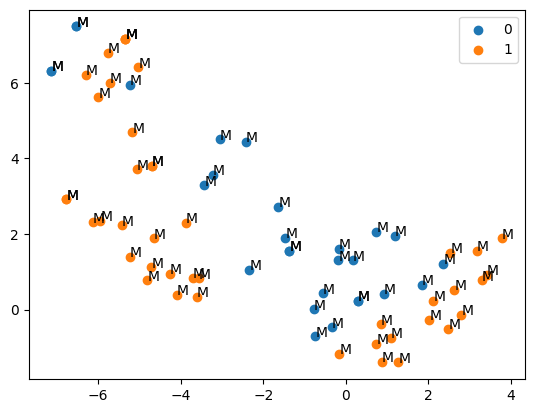

In [156]:
plot(matrix, R[1], R[0],19)